# 06 — Gap-Removed Efficiency, and the Months

When a night runs below ~80% efficiency it's one of two different problems:

1. **Overhead** — the slew/processing didn't fully overlap the ~30 s readout. This is a *machine* problem: a well-tuned telescope moves in under 20 s, inside the readout, so it costs nothing extra.
2. **Stoppage** — the telescope simply wasn't observing: a fault, a weather closure, a script restart. This is a *different* problem with a different fix.

The raw per-night efficiency (notebook 04) mixes the two. Here we split them using the **gap between consecutive exposures**: `gap = next start − (this start + exptime)`. Small gaps are overhead; large gaps are stoppages. Removing stoppage time from the denominator gives a second number — **running efficiency**: how efficient the telescope was *while it was actually running*.

$$\text{running efficiency} = \frac{\text{time exposing}}{\text{night span} - \text{time in gaps} > 120\,\text{s}}$$

Then we ask whether the months differ — and whether they differ in *overhead* or in *stoppages*.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/des-exposures.csv.gz')
df['dt'] = pd.to_datetime(df['datetime'], errors='coerce')
df = df[df['dt'].dt.year >= 2012]
df['night'] = (df['dt'] - pd.Timedelta(hours=12)).dt.date
df['end'] = df['dt'] + pd.to_timedelta(df['exptime'], unit='s')
df = df.sort_values('dt')

# gap after each exposure, within its night
df['next_start'] = df.groupby('night')['dt'].shift(-1)
df['gap_s'] = (df['next_start'] - df['end']).dt.total_seconds()
gaps = df['gap_s'].dropna()
print(f"{len(gaps)} gaps   median {gaps.median():.0f}s   p90 {gaps.quantile(0.9):.0f}s   p95 {gaps.quantile(0.95):.0f}s")

105037 gaps   median 30s   p90 62s   p95 113s


## Where is the 120 s line coming from?

Look at the gap distribution before picking the threshold. The gaps pile up hard at **30 s** — that's the DECam readout, and it means the slews *are* mostly hiding inside the readout (the <20 s goal). The pile thins out fast and is nearly empty by ~2 minutes; beyond that is a long thin tail of stoppages stretching to hours. 120 s sits in the valley between the two regimes.

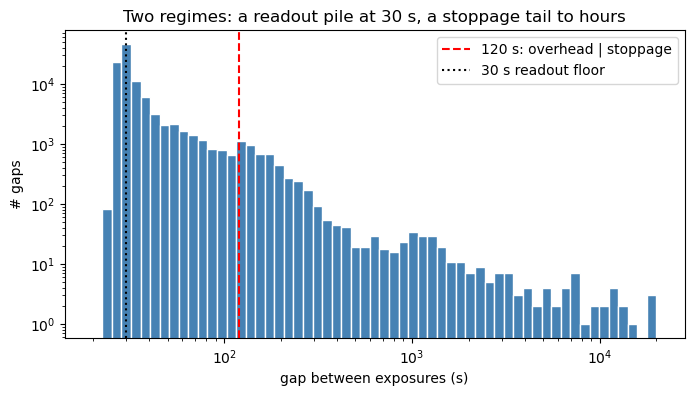

gaps > 120 s: 4.6% of gaps, 30% of all dead time


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.logspace(np.log10(20), np.log10(20000), 60)
ax.hist(gaps[gaps > 0], bins=bins, color='steelblue', edgecolor='white')
ax.axvline(120, color='red', ls='--', label='120 s: overhead | stoppage')
ax.axvline(30, color='k', ls=':', label='30 s readout floor')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('gap between exposures (s)')
ax.set_ylabel('# gaps')
ax.set_title('Two regimes: a readout pile at 30 s, a stoppage tail to hours')
ax.legend()
plt.show()

print(f"gaps > 120 s: {(gaps > 120).mean()*100:.1f}% of gaps, "
      f"{gaps[gaps > 120].sum()/gaps[gaps > 0].sum()*100:.0f}% of all dead time")

## The cumulative view of dead time

Sort every gap by length and accumulate. This answers: *if we could fix all stoppages longer than X, how much dead time would we get back?* The tail is where the leverage is — a few percent of the gaps carry a third of the dead time.

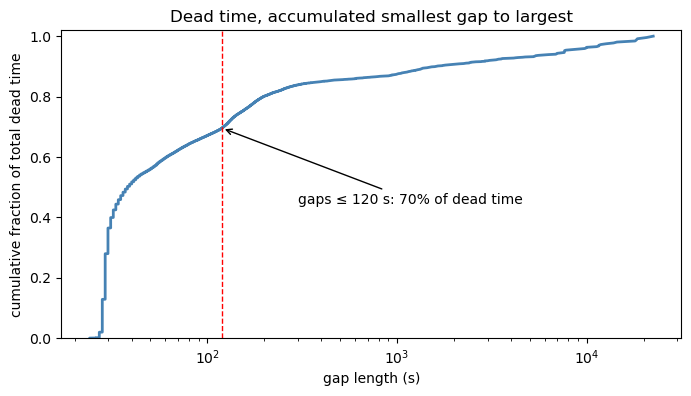

In [5]:
g = np.sort(gaps[gaps > 0].values)
cum = np.cumsum(g) / g.sum()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(g, cum, color='steelblue', lw=2)
ax.axvline(120, color='red', ls='--', lw=1)
frac_below = cum[np.searchsorted(g, 120)]
ax.annotate(f'gaps ≤ 120 s: {frac_below*100:.0f}% of dead time',
            xy=(120, frac_below), xytext=(300, frac_below - 0.25),
            arrowprops=dict(arrowstyle='->'))
ax.set_xscale('log')
ax.set_xlabel('gap length (s)')
ax.set_ylabel('cumulative fraction of total dead time')
ax.set_title('Dead time, accumulated smallest gap to largest')
ax.set_ylim(0, 1.02)
plt.show()

## Per night: raw vs running efficiency

Same night table as notebook 04, plus a stoppage column. `eff` divides by the whole span; `eff_run` divides by the span minus stoppage time.

In [6]:
nights = df.groupby('night').agg(
    n=('expnum', 'size'),
    observing_s=('exptime', 'sum'),
    start=('dt', 'min'),
    end=('end', 'max'),
    stoppage_s=('gap_s', lambda s: s[s > 120].sum()),
)
nights['span_s'] = (nights['end'] - nights['start']).dt.total_seconds()
nights = nights[nights['n'] >= 10]
nights['eff'] = nights['observing_s'] / nights['span_s']
nights['eff_run'] = nights['observing_s'] / (nights['span_s'] - nights['stoppage_s'])

print(f"{len(nights)} nights")
print(f"median raw eff      {nights['eff'].median():.2f}   nights >= 0.8: {(nights['eff'] >= 0.8).mean()*100:.0f}%")
print(f"median running eff  {nights['eff_run'].median():.2f}   nights >= 0.8: {(nights['eff_run'] >= 0.8).mean()*100:.0f}%")

705 nights
median raw eff      0.71   nights >= 0.8: 6%
median running eff  0.75   nights >= 0.8: 23%


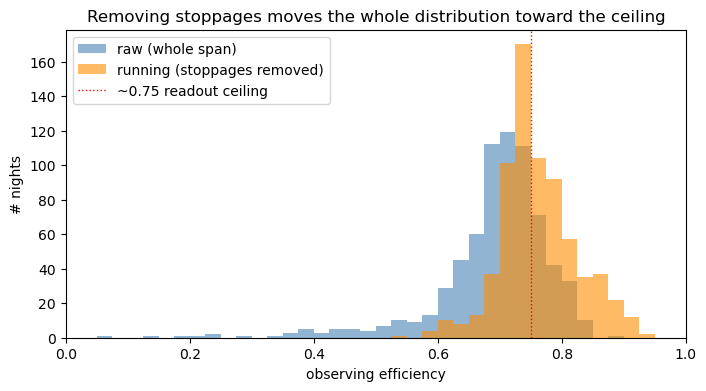

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 41)
ax.hist(nights['eff'], bins=bins, color='steelblue', alpha=0.6, label='raw (whole span)')
ax.hist(nights['eff_run'], bins=bins, color='darkorange', alpha=0.6, label='running (stoppages removed)')
ax.axvline(0.75, color='red', ls=':', lw=1, label='~0.75 readout ceiling')
ax.set_xlim(0, 1)
ax.set_xlabel('observing efficiency')
ax.set_ylabel('# nights')
ax.set_title('Removing stoppages moves the whole distribution toward the ceiling')
ax.legend(loc='upper left')
plt.show()

Each night sits above the diagonal by however much of its span was stoppage. The nights far off the diagonal are the interesting ones: they looked terrible in the raw number, but the telescope was fine — it just stood still for a while.

Two things here look wrong but aren't. **Nights above the 0.75/0.8 ceiling are real**: that ceiling only applies to 90 s exposures, and the high nights are long-exposure supernova sequences (median exptime 200 s on the >0.8 nights vs 90 s overall) that amortize the same ~30 s readout over more than twice the exposure — their ceiling is ~0.9. And running efficiency can sit above the *raw* ceiling anyway, because removing stoppage time shrinks the denominator.

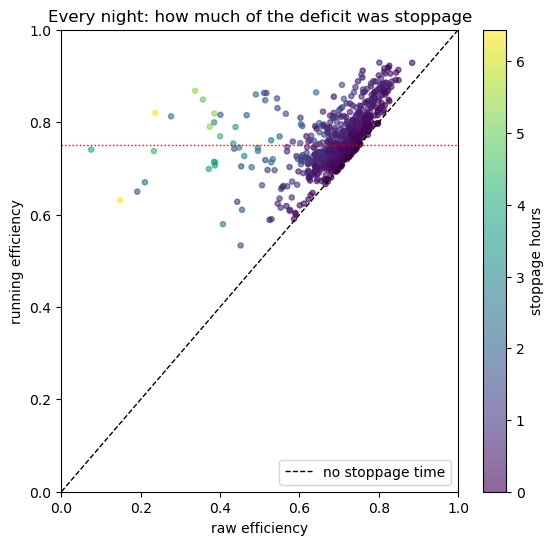

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 6))
sc = ax.scatter(nights['eff'], nights['eff_run'], s=14, alpha=0.6,
                c=nights['stoppage_s'] / 3600, cmap='viridis')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='no stoppage time')
ax.axhline(0.75, color='red', ls=':', lw=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('raw efficiency')
ax.set_ylabel('running efficiency')
ax.set_title('Every night: how much of the deficit was stoppage')
fig.colorbar(sc, label='stoppage hours')
ax.legend(loc='lower right')
plt.show()

## The months

DES observes August through February. Three questions per month: what was the raw efficiency, what was the running efficiency, and how much time per night went to stoppages?

In [9]:
t = nights.reset_index()
t['night_dt'] = pd.to_datetime(t['night'])
t['month'] = t['night_dt'].dt.month

order = [8, 9, 10, 11, 12, 1, 2]                      # the observing season, in order
names = ['Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb']
t = t[t['month'].isin(order)]                          # drops one stray July night

by = t.groupby('month').agg(eff=('eff', 'median'), eff_run=('eff_run', 'median'),
                            stop_h=('stoppage_s', lambda s: s.median() / 3600),
                            nights=('eff', 'size')).reindex(order)
by.index = names
by

,eff,eff_run,stop_h,nights
Aug,0.730757,0.797977,0.337778,55
Sep,0.686584,0.744999,0.604722,115
Oct,0.693264,0.748168,0.628333,108
Nov,0.691351,0.739376,0.481944,114
Dec,0.699097,0.743604,0.371111,131
Jan,0.725817,0.771043,0.172639,120
Feb,0.727053,0.745729,0.125556,61


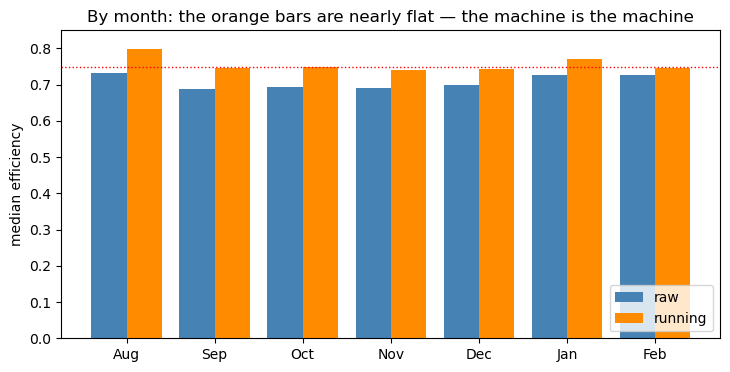

In [10]:
x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(x - 0.2, by['eff'], width=0.4, color='steelblue', label='raw')
ax.bar(x + 0.2, by['eff_run'], width=0.4, color='darkorange', label='running')
ax.axhline(0.75, color='red', ls=':', lw=1)
ax.set_xticks(x, names)
ax.set_ylim(0, 0.85)
ax.set_ylabel('median efficiency')
ax.set_title('By month: the orange bars are nearly flat — the machine is the machine')
ax.legend(loc='lower right')
plt.show()

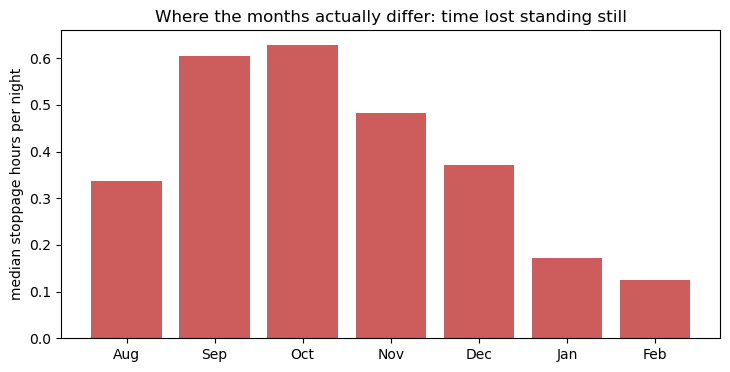

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(names, by['stop_h'], color='indianred')
ax.set_ylabel('median stoppage hours per night')
ax.set_title('Where the months actually differ: time lost standing still')
plt.show()

**Reading it:** raw efficiency looks mildly seasonal, but the running efficiency is nearly flat across the season (~0.74–0.80). The seasonal signal lives almost entirely in the stoppage hours: a typical **September or October night loses ~0.6 h** to stoppages, four times the ~0.15 h of a January/February night. That's Chilean spring weather and early-season shakedown, not the telescope getting slower. So the two-number split does its job: overhead is a constant of the machine, and the month-to-month story is entirely about how often the machine had to stop.

## Animated: the anatomy of one night

Watch a real night assemble exposure by exposure. Blue blocks are open shutter; the white slivers between them are the 30 s readouts; the red span is a stoppage. The title tracks the raw efficiency as the night accumulates — watch it drop when the stoppage arrives and never fully recover.

In [13]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
plt.rcParams['animation.embed_limit'] = 60

# pick a typical night that contains a real stoppage: raw eff near the median,
# 0.5-1.5 h of stoppage time
cand = nights[(nights['stoppage_s'].between(1800, 5400)) & (nights['n'] > 150)]
pick = cand.iloc[(cand['eff'] - nights['eff'].median()).abs().argsort()].index[0]
d = df[df['night'] == pick].sort_values('dt')
t0 = d['dt'].min()
starts = (d['dt'] - t0).dt.total_seconds() / 3600
durs = d['exptime'].values / 3600
print(f"night {pick}: {len(d)} exposures, raw eff {nights.loc[pick, 'eff']:.2f}, "
      f"running eff {nights.loc[pick, 'eff_run']:.2f}")

fig, ax = plt.subplots(figsize=(9, 2.6))
step = int(np.ceil(len(d) / 45))

def draw(frame):
    ax.clear()
    k = min((frame + 1) * step, len(d))
    ax.broken_barh(list(zip(starts[:k], durs[:k])), (0, 1), color='steelblue')
    stops = d['gap_s'].values[:k - 1]
    for i in np.where(stops > 120)[0]:
        ax.axvspan(starts.iloc[i] + durs[i], starts.iloc[i + 1], color='red', alpha=0.3)
    elapsed = starts.iloc[k - 1] + durs[k - 1]
    eff_so_far = durs[:k].sum() / elapsed
    ax.set_xlim(0, (starts.iloc[-1] + durs[-1]) * 1.02)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel('hours since first exposure')
    ax.set_title(f'night {pick} — {k} exposures in, efficiency so far: {eff_so_far:.2f}')

anim = FuncAnimation(fig, draw, frames=45, interval=90)
plt.close(fig)
HTML(anim.to_jshtml(default_mode='once'))

night 2017-09-17: 266 exposures, raw eff 0.71, running eff 0.76


## Animated: the whole survey, night by night

Every night of DES appears in the order it happened — raw efficiency in blue, and the same night with stoppages removed in orange. The vertical distance between the two clouds is the stoppage time; the off-season gaps are the winters.

In [14]:
ts = t.sort_values('night_dt').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9.5, 4))
step = int(np.ceil(len(ts) / 48))

def draw(frame):
    ax.clear()
    k = min((frame + 1) * step, len(ts))
    ax.scatter(ts['night_dt'][:k], ts['eff_run'][:k], s=10, alpha=0.4, color='darkorange',
               label='running')
    ax.scatter(ts['night_dt'][:k], ts['eff'][:k], s=10, alpha=0.5, color='steelblue',
               label='raw')
    ax.axhline(0.75, color='red', ls=':', lw=1)
    ax.set_xlim(ts['night_dt'].min() - pd.Timedelta('30D'),
                ts['night_dt'].max() + pd.Timedelta('30D'))
    ax.set_ylim(0, 1)
    ax.set_ylabel('observing efficiency')
    ax.set_title(f'{k} of {len(ts)} nights')
    ax.legend(loc='lower right')

anim = FuncAnimation(fig, draw, frames=48, interval=80)
plt.close(fig)
HTML(anim.to_jshtml(default_mode='once'))

## Where this goes

- **Two numbers per night instead of one**: raw efficiency (did the night deliver?) and running efficiency (was the machine tuned?). A scheduler should be judged on the first; a telescope-operations team on the second.
- The 120 s threshold was read off the gap histogram, not chosen — worth re-checking on any other instrument before reusing.
- Still open from notebook 04: the denominator is first-to-last exposure, not astronomical darkness, so stoppages *before the first or after the last exposure* of the night remain invisible. Twilight-to-twilight would catch those.